In [1]:
from pathlib import Path
import os

# If notebook runs from test_notebooks/, move to repo root first.
if Path.cwd().name == 'test_notebooks':
    os.chdir('..')

print('Current working directory:', Path.cwd())


Current working directory: /home/bhchen/LearnKalmanGain


Saved posterior grid image to: save/doubling1d_results/doubling1d_results_grid_step100_with_enkf_and_legend.png


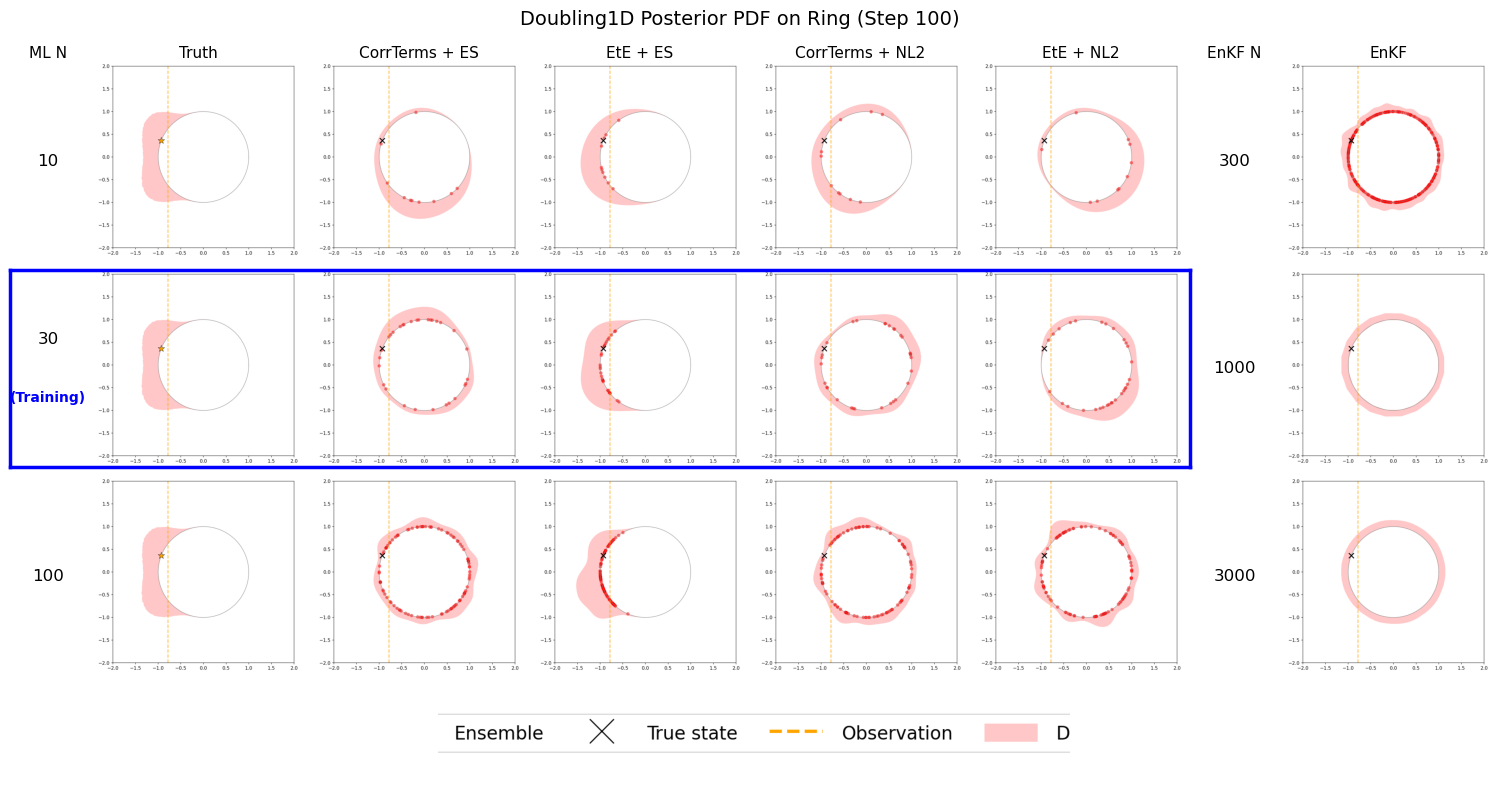

Saved posterior grid image to: save/doubling1d_results/doubling1d_results_grid_step150_with_enkf_and_legend.png


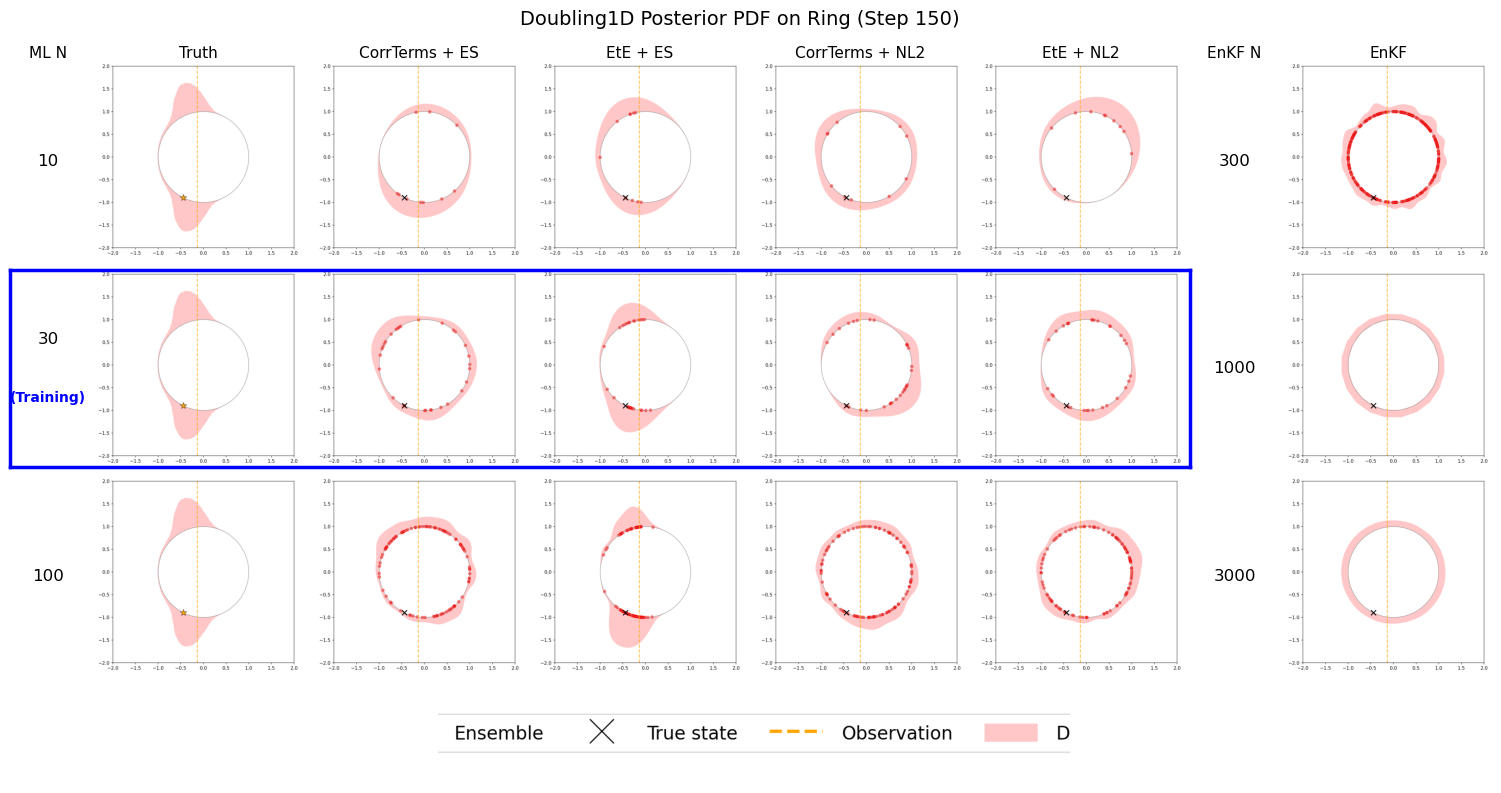

Saved posterior grid image to: save/doubling1d_results/doubling1d_results_grid_step200_with_enkf_and_legend.png


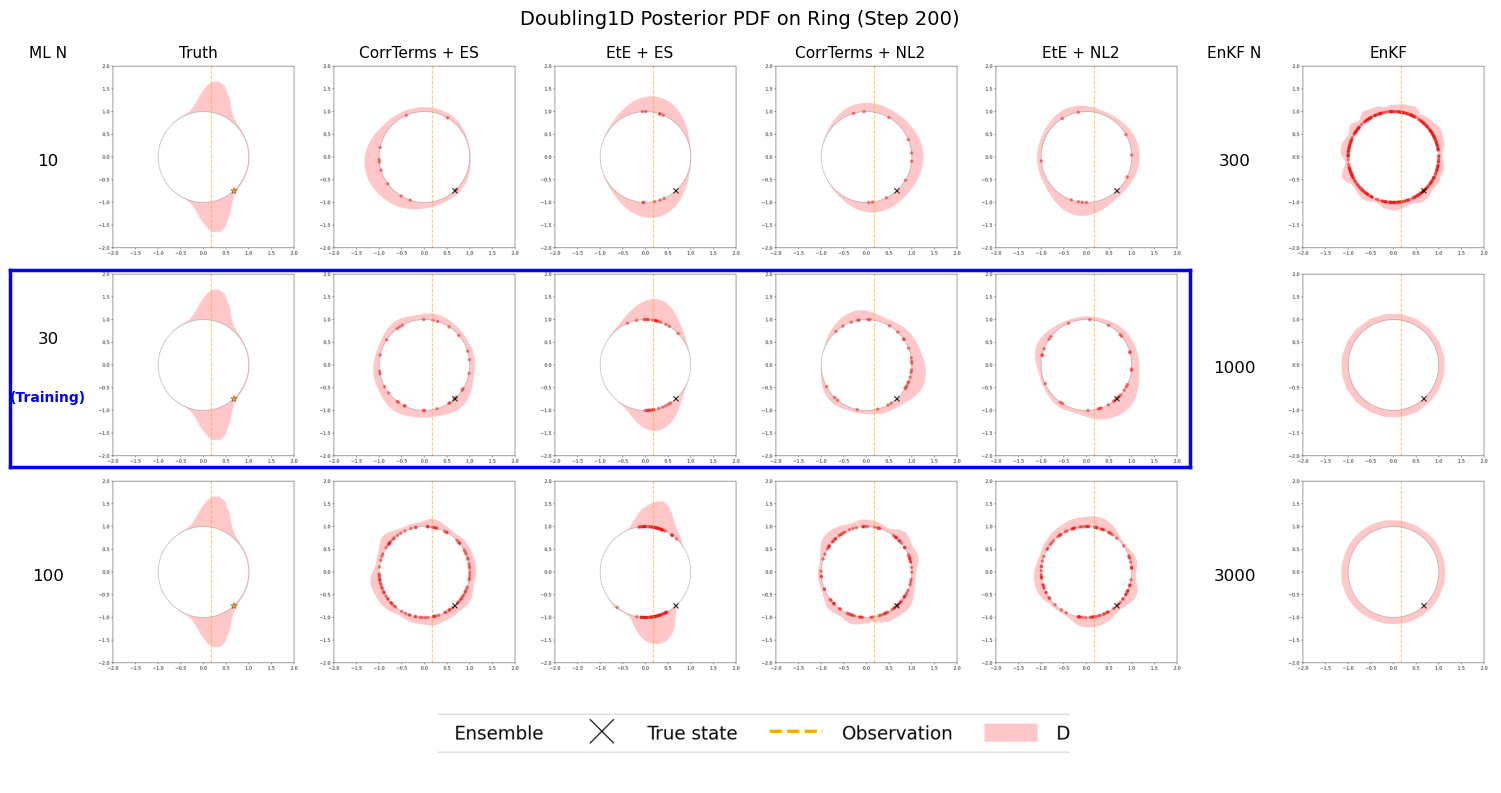

Saved prior grid image to: save/doubling1d_results/doubling1d_results_grid_step100_prior_with_enkf_and_legend.png


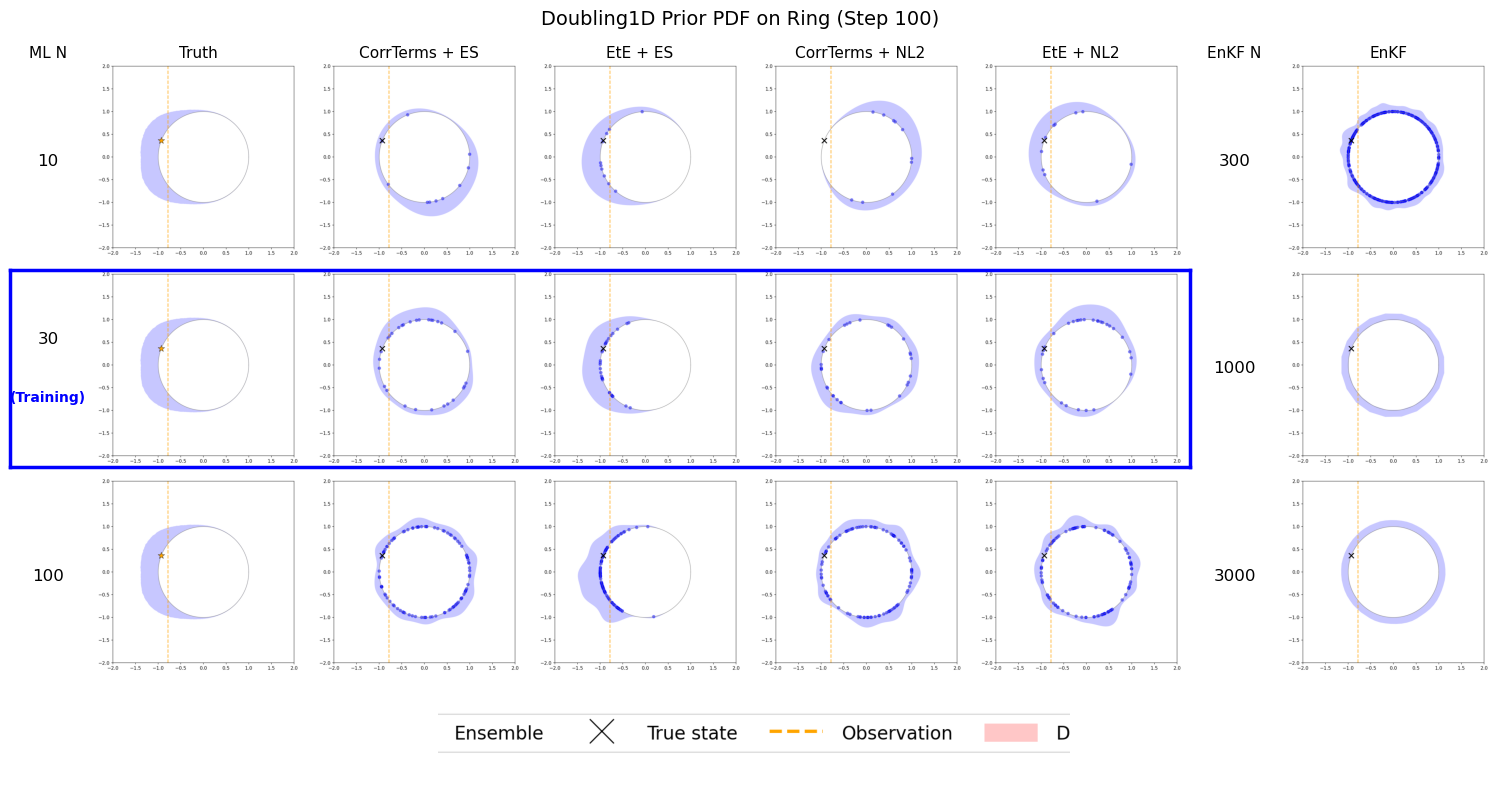

Saved prior grid image to: save/doubling1d_results/doubling1d_results_grid_step150_prior_with_enkf_and_legend.png


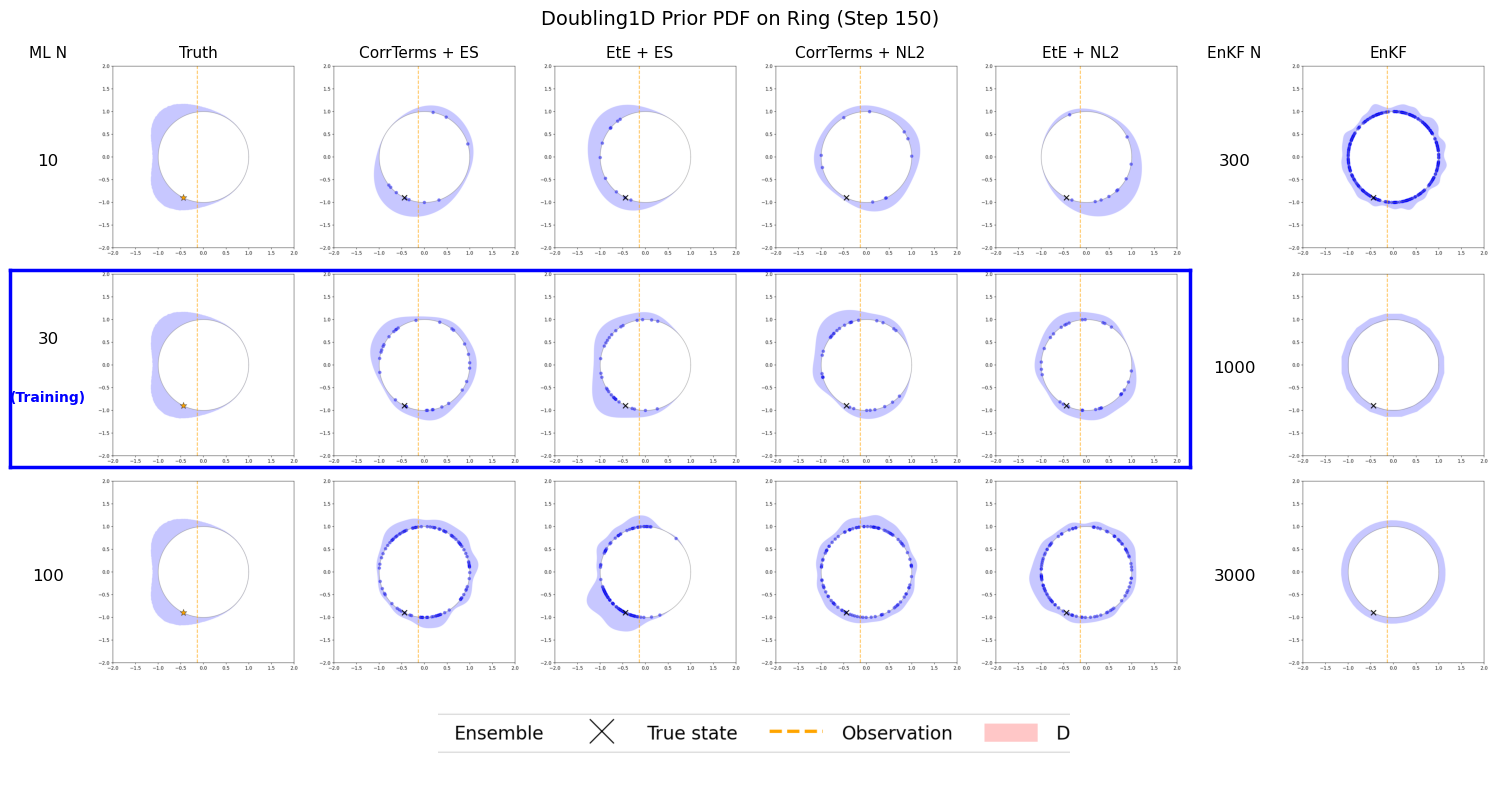

Saved prior grid image to: save/doubling1d_results/doubling1d_results_grid_step200_prior_with_enkf_and_legend.png


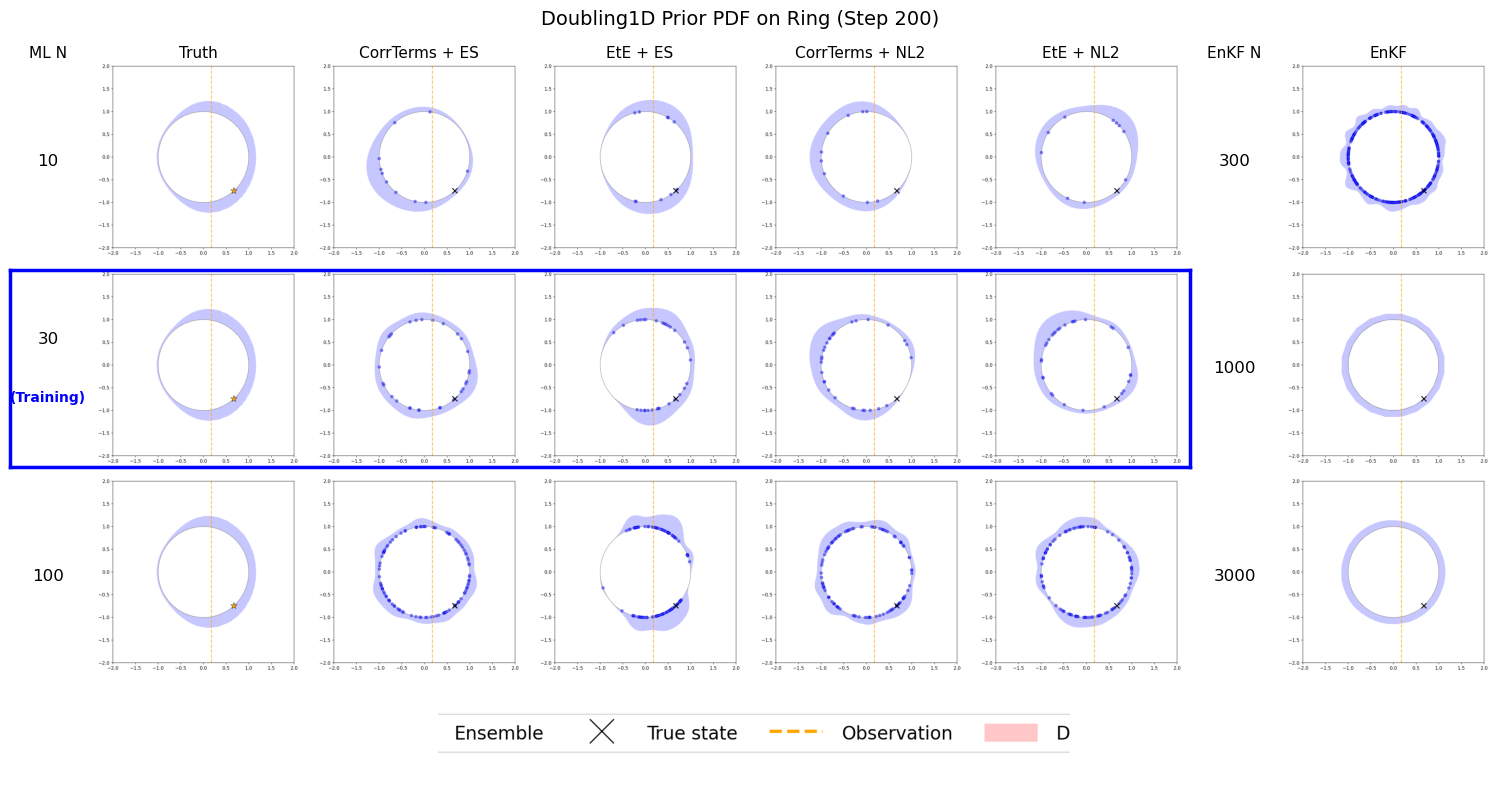

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

base_dir = Path('save/doubling1d_results')
enkf_dir = Path('save/benchmark_doubling1d_0.2_EnKF')
legend_path = enkf_dir / 'post_density_legend.png'
truth_dir = Path('save/doubling1d_pf_vis')

methods = [
    ('CorrTerms + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_CorrTermsNone_cos2pi'),
    ('EtE + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_CorrTermsNone_cos2pi'),
    ('EtE + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_EtE-LResNone_cos2pi'),
]

steps = [100, 150, 200]
ml_ensemble_sizes = [10, 30, 100]
enkf_ensemble_sizes = [300, 1000, 3000]
seed = 0
stages = [
    ('Posterior', 'post', 'POST'),
    ('Prior', 'prior', 'PRIOR'),
]

legend_crop = {
    'left': 0.2,
    'right': 0.2,
    'top': 0.2,
    'bottom': 0.2,
}
legend_height_ratio = 0.5

if len(ml_ensemble_sizes) != len(enkf_ensemble_sizes):
    raise ValueError('ML and EnKF ensemble-size lists must have the same length.')

for required_path in (base_dir, enkf_dir, truth_dir):
    if not required_path.exists():
        raise FileNotFoundError(f'Missing required directory: {required_path}')

if not legend_path.exists():
    raise FileNotFoundError(f'Missing legend image: {legend_path}')


def crop_image(image, crop):
    h, w = image.shape[:2]
    left = int(w * crop.get('left', 0.0))
    right = int(w * crop.get('right', 0.0))
    top = int(h * crop.get('top', 0.0))
    bottom = int(h * crop.get('bottom', 0.0))

    if left + right >= w:
        raise ValueError('Legend crop left+right ratio exceeds 1.0.')
    if top + bottom >= h:
        raise ValueError('Legend crop top+bottom ratio exceeds 1.0.')

    x_end = w - right if right > 0 else w
    y_end = h - bottom if bottom > 0 else h
    return image[top:y_end, left:x_end]


def get_truth_path(step, truth_tag):
    timestep = step - 1
    return truth_dir / (
        f'sigma_y0.2_batch64_len200_pfN1000000_timestep{timestep}_42_g0_{truth_tag}_0_ring_pdf_on_ring_nohist.png'
    )


def get_ml_path(method_folder, ml_n, step, stage_key):
    prefix = f'test_{ml_n}_{seed}'
    if stage_key == 'prior':
        prefix += '_prior'
    return base_dir / method_folder / f'{prefix}_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'


def get_enkf_path(enkf_n, step, stage_key):
    stage_token = 'classic_prior' if stage_key == 'prior' else 'classic'
    return enkf_dir / f'test_{enkf_n}_0_{stage_token}_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'


def save_grid_image(step, stage_label, stage_key, truth_tag, legend_img):
    truth_path = get_truth_path(step, truth_tag)
    if not truth_path.exists():
        raise FileNotFoundError(f'Missing truth image for {stage_label.lower()} step {step}: {truth_path}')

    nrows = len(ml_ensemble_sizes)
    ncols = 1 + 1 + len(methods) + 1 + 1
    width_ratios = [0.35, 1, 1, 1, 1, 1, 0.38, 1]

    fig = plt.figure(figsize=(15.2, 8.1))
    gs = fig.add_gridspec(
        nrows=nrows + 1,
        ncols=ncols,
        width_ratios=width_ratios,
        height_ratios=[1] * nrows + [legend_height_ratio],
    )
    axes = [[fig.add_subplot(gs[r, c]) for c in range(ncols)] for r in range(nrows)]

    column_titles = ['ML N', 'Truth'] + [m[0] for m in methods] + ['EnKF N', 'EnKF']
    for col, title in enumerate(column_titles):
        axes[0][col].set_title(title, fontsize=11, pad=3)

    missing = []
    truth_img = plt.imread(truth_path)

    for row, (ml_n, enkf_n) in enumerate(zip(ml_ensemble_sizes, enkf_ensemble_sizes)):
        ax_ml_n = axes[row][0]
        ax_ml_n.axis('off')
        if ml_n == 30:
            ax_ml_n.text(0.5, 0.65, str(ml_n), ha='center', va='center', fontsize=12)
            ax_ml_n.text(0.5, 0.35, '(Training)', ha='center', va='center', fontsize=10, color='blue', weight='bold')
            box_ax = fig.add_subplot(gs[row, 0:6], zorder=10)
            box_ax.set_facecolor('none')
            box_ax.set_xticks([])
            box_ax.set_yticks([])
            for spine in box_ax.spines.values():
                spine.set_edgecolor('blue')
                spine.set_linewidth(2.5)
        else:
            ax_ml_n.text(0.5, 0.5, str(ml_n), ha='center', va='center', fontsize=12)

        axes[row][1].imshow(truth_img)
        axes[row][1].axis('off')

        for i, (_, method_folder) in enumerate(methods):
            col = 2 + i
            ax = axes[row][col]
            image_path = get_ml_path(method_folder, ml_n, step, stage_key)
            if not image_path.exists():
                missing.append(str(image_path))
                ax.axis('off')
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
                continue
            ax.imshow(plt.imread(image_path))
            ax.axis('off')

        ax_enkf_n = axes[row][2 + len(methods)]
        ax_enkf_n.axis('off')
        ax_enkf_n.text(0.5, 0.5, str(enkf_n), ha='center', va='center', fontsize=12)

        ax_enkf = axes[row][3 + len(methods)]
        enkf_path = get_enkf_path(enkf_n, step, stage_key)
        if not enkf_path.exists():
            missing.append(str(enkf_path))
            ax_enkf.axis('off')
            ax_enkf.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
        else:
            ax_enkf.imshow(plt.imread(enkf_path))
            ax_enkf.axis('off')

    if missing:
        raise FileNotFoundError(
            f'Some expected images were not found for {stage_label.lower()} step {step}:\n' + '\n'.join(missing)
        )

    legend_ax = fig.add_subplot(gs[nrows, :])
    legend_ax.imshow(legend_img, aspect='equal')
    legend_ax.axis('off')

    fig.suptitle(f'Doubling1D {stage_label} PDF on Ring (Step {step})', fontsize=14, y=0.985)
    fig.subplots_adjust(left=0.02, right=0.998, top=0.92, bottom=0.03, wspace=0.02, hspace=0.06)

    if stage_key == 'post':
        output_path = base_dir / f'doubling1d_results_grid_step{step}_with_enkf_and_legend.png'
    else:
        output_path = base_dir / f'doubling1d_results_grid_step{step}_{stage_key}_with_enkf_and_legend.png'

    fig.savefig(output_path, dpi=260, bbox_inches='tight', pad_inches=0.02)
    print(f'Saved {stage_label.lower()} grid image to: {output_path}')
    plt.show()


legend_img = crop_image(plt.imread(legend_path), legend_crop)

for stage_label, stage_key, truth_tag in stages:
    for step in steps:
        save_grid_image(step, stage_label, stage_key, truth_tag, legend_img)


/tmp/ipykernel_621217/2025559113.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(path, map_location='cpu')


Saved metrics figure to: save/doubling1d_results/doubling1d_metrics_vs_N.png


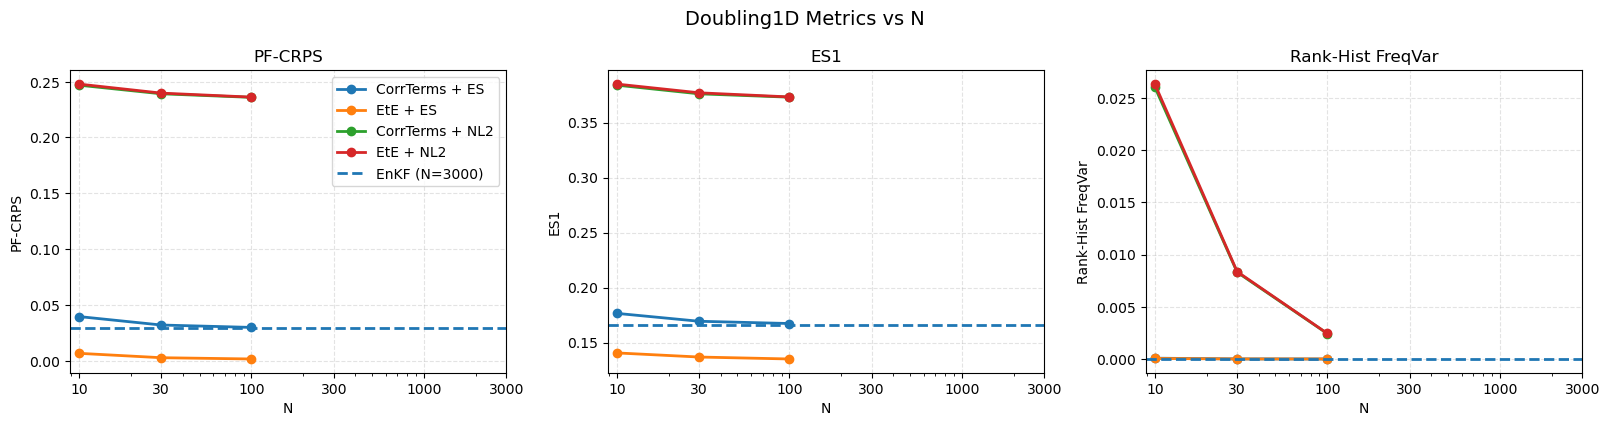

In [3]:
from pathlib import Path
import math
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import torch

base_dir = Path('save/doubling1d_results')
enkf_dir = Path('save/benchmark_doubling1d_0.2_EnKF')

methods = [
    ('CorrTerms + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_CorrTermsNone_cos2pi'),
    ('EtE + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_CorrTermsNone_cos2pi'),
    ('EtE + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_EtE-LResNone_cos2pi'),
]

metric_specs = [
    ('PF-CRPS', ('mean_pf_crps', 'pf_crps')),
    ('ES1', ('mean_es1', 'es1')),
    ('Rank-Hist FreqVar', ('rank_freq_var',)),
]


def extract_metric(payload, candidate_keys):
    metric_sources = [payload.get('nn', {}), payload.get('test_results', {})]
    for key in candidate_keys:
        for source in metric_sources:
            if key in source:
                return float(source[key])
    return float('nan')


def collect_metric_series(folder):
    records = []
    for path in sorted(folder.glob('output_records_*.pt')):
        n_str = path.stem.replace('output_records_', '')
        try:
            ensemble_size = int(n_str)
        except ValueError:
            continue

        payload = torch.load(path, map_location='cpu')
        row = {'N': ensemble_size}
        for metric_label, candidate_keys in metric_specs:
            row[metric_label] = extract_metric(payload, candidate_keys)
        records.append(row)

    if not records:
        raise FileNotFoundError(f'No output_records_*.pt files found in {folder}')

    records.sort(key=lambda row: row['N'])
    return records


series_map = {
    label: collect_metric_series(base_dir / folder_name)
    for label, folder_name in methods
}
series_map['EnKF'] = collect_metric_series(enkf_dir)
enkf_reference_row = max(series_map['EnKF'], key=lambda row: row['N'])

all_ns = sorted({row['N'] for rows in series_map.values() for row in rows})
fig, axes = plt.subplots(1, len(metric_specs), figsize=(5.4 * len(metric_specs), 4.3))
if len(metric_specs) == 1:
    axes = [axes]

for ax, (metric_label, _) in zip(axes, metric_specs):
    for series_label, rows in series_map.items():
        if series_label == 'EnKF':
            enkf_value = enkf_reference_row[metric_label]
            if math.isfinite(enkf_value):
                ax.axhline(enkf_value, linewidth=2, linestyle='--', label=f"EnKF (N={enkf_reference_row['N']})")
            continue

        valid_points = [
            (row['N'], row[metric_label])
            for row in rows
            if math.isfinite(row[metric_label])
        ]
        if not valid_points:
            continue

        xs, ys = zip(*valid_points)
        ax.plot(xs, ys, marker='o', linewidth=2, label=series_label)

    ax.set_title(metric_label)
    ax.set_xlabel('N')
    ax.set_ylabel(metric_label)
    ax.set_xscale('log')
    ax.set_xticks(all_ns)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    ax.grid(True, linestyle='--', alpha=0.35)

axes[0].legend(loc='best')
fig.suptitle('Doubling1D Metrics vs N', fontsize=14)
fig.tight_layout()

output_path = base_dir / 'doubling1d_metrics_vs_N.png'
fig.savefig(output_path, dpi=220, bbox_inches='tight')
print(f'Saved metrics figure to: {output_path}')
plt.show()
